# Libraries and Data

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
source1 = pd.read_csv("medical_insurance.csv")
# source2 = pd.read_csv("medical-charges.csv")

df = pd.concat([source1], ignore_index=True)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


# Data Preprocessing 

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,47,0,45.320,1,0,2,8569.86180
2768,21,0,34.600,0,0,3,2020.17700
2769,19,1,26.030,1,1,1,16450.89470
2770,23,1,18.715,0,0,1,21595.38229


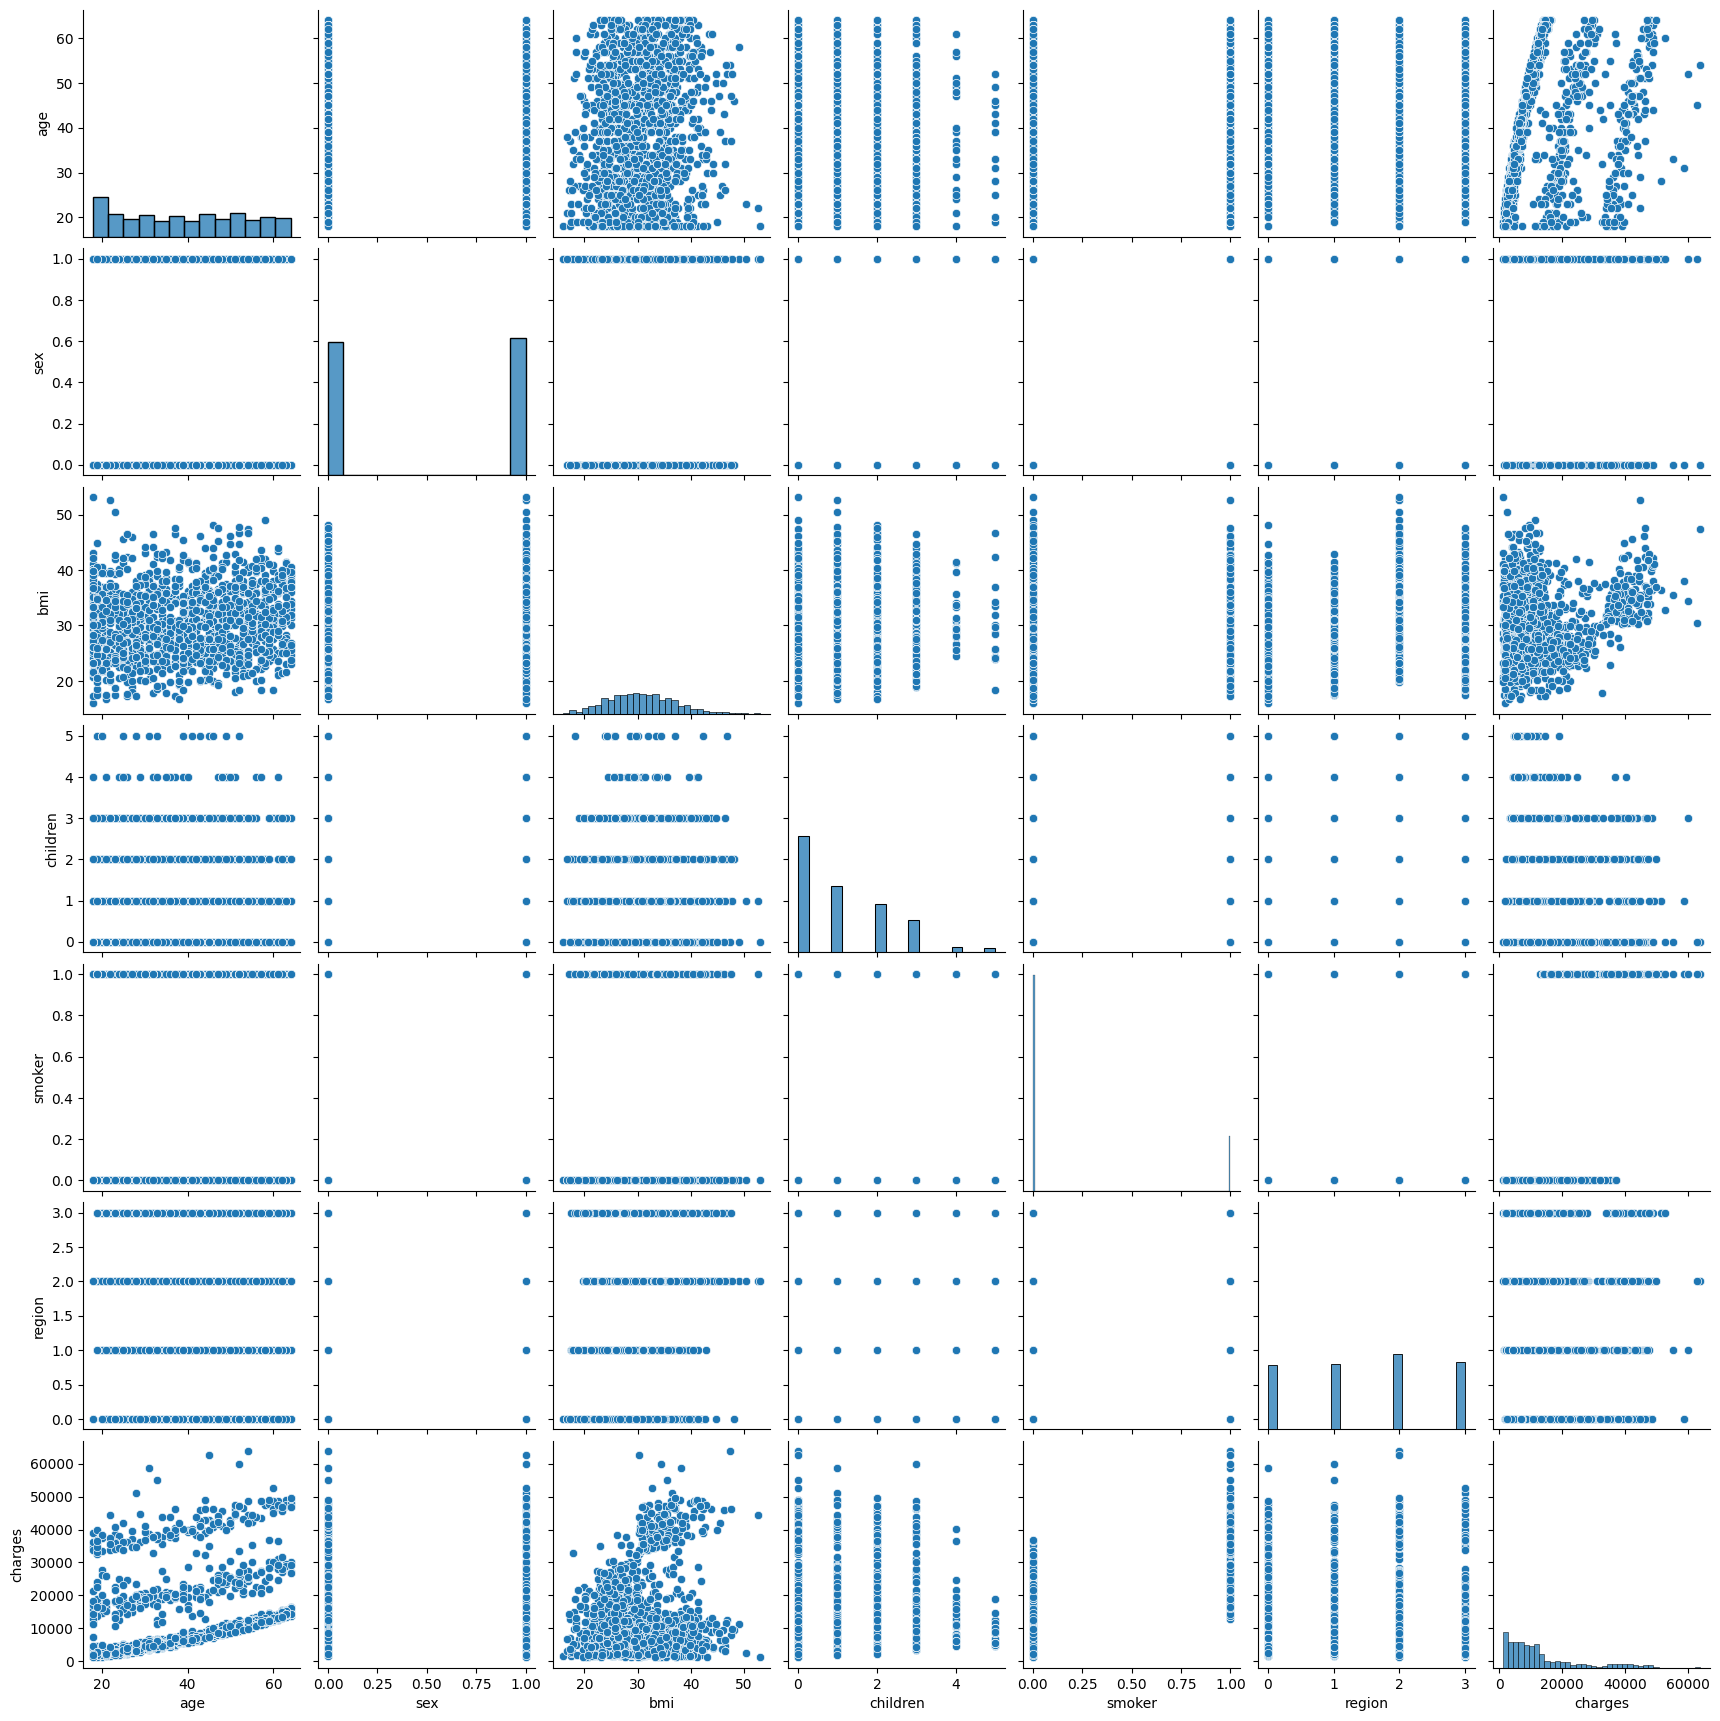

In [8]:
sns.pairplot(df)
plt.show()

In [9]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['age', 'bmi']] = scaler.fit_transform(df[['age', 'bmi']])
df

,age,sex,bmi,children,smoker,region,charges
0,-1.428353,0,-0.457114,0,1,3,16884.92400
1,-1.499381,1,0.500731,1,0,2,1725.55230
2,-0.789099,1,0.375085,3,0,2,4449.46200
3,-0.433959,1,-1.304814,0,0,1,21984.47061
4,-0.504987,1,-0.297201,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,0.560436,0,2.385417,1,0,2,8569.86180
2768,-1.286297,0,0.636167,0,0,3,2020.17700
2769,-1.428353,1,-0.762253,1,1,1,16450.89470
2770,-1.144240,1,-1.955887,0,0,1,21595.38229


In [10]:
# Train Test Split

from sklearn.model_selection import train_test_split



X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df[['charges']]

X, y

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

In [11]:
from sklearn.linear_model import LinearRegression

LRE = LinearRegression()

model = LRE.fit(X_train, Y_train)
model.intercept_, model.coef_

(array([8447.77098535]),
 array([[ 3590.84068899,   -69.83943492,  1956.92569237,   458.66712882,
         23841.41059094,  -388.86163206]]))

In [12]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_train)
train_accuracy = r2_score(Y_train, y_pred)

y_pred = model.predict(X_test)
test_accuracy = r2_score(Y_test, y_pred)

print(f"""
Train Accuracy : {train_accuracy}
Test Accuracy : {test_accuracy}
""")


Train Accuracy : 0.753395406601626
Test Accuracy : 0.7398864322395977



In [13]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor(random_state=42)

regressor = RFR.fit(X_train, Y_train )

pred = regressor.predict(np.array([[-0.513149, 1, -0.292556,0, 0, 1]]) )
training_score = regressor.score(X_train, Y_train.values.ravel())
test_score = regressor.score(X_test, Y_test.values.ravel())

print(f"Score Is {training_score} {test_score}")

c:\Users\kgliv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Score Is 0.9921304414371793 0.9509844621912971


c:\Users\kgliv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [14]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(model, 'regressor.pkl')

['regressor.pkl']